# FLOWER CLASSIFIER

## Imports

In [3]:
import copy
import os
import tarfile
import matplotlib.pyplot as plt
import numpy as np
import requests
import scipy
from PIL import Image
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, Subset, random_split, DataLoader
from torchvision import transforms, models

!pip install optuna
import optuna

# import helper_utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 8.9 MB/s eta 0:00:00


## Data access

In [ ]:
def download_dataset():
    data_dir = "flower_data"
    image_folder_path = os.path.join(data_dir, "jpg")
    labels_file_path = os.path.join(data_dir, "imagelabels.mat")
    tgz_path = os.path.join(data_dir, "102flowers.tgz")

    if os.path.exists(image_folder_path) and os.path.exists(labels_file_path):
        print(f"Dataset already exists. Loading locally from '{data_dir}'.")
        return

    print("Dataset not found locally. Downloading...")

    image_url = "https://www.robots.ox.ac.uk/~vgg/data/flowers/102/102flowers.tgz"
    labels_url = "https://www.robots.ox.ac.uk/~vgg/data/flowers/102/imagelabels.mat"

    os.makedirs(data_dir, exist_ok=True)

    print("Downloading images...")
    response = requests.get(image_url)
    with open(tgz_path, "wb") as file:
        file.write(response.content)

    print("Extracting files...")
    with tarfile.open(tgz_path, "r:gz") as tar:
        tar.extractall(data_dir)

    print("Downloading labels...")
    response = requests.get(labels_url)
    with open(labels_file_path, "wb") as file:
        file.write(response.content)

    print(f"Dataset downloaded and extracted to '{data_dir}'.")

In [ ]:
# Call the function to download and prepare the dataset.
download_dataset()

Dataset not found locally. Downloading...
Extracting files...


/tmp/ipykernel_9675/2434463611.py:25: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(data_dir)


Dataset downloaded and extracted to 'flower_data'.


In [ ]:
path_dataset = './flower_data'

# Display the folder structure of the dataset directory up to a depth of one.
#helper_utils.print_data_folder_structure(path_dataset, max_depth=1)

## Device Setup

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Data Exploration

In [ ]:
# Load labels from the .mat file
labels_mat = scipy.io.loadmat(os.path.join(path_dataset, "imagelabels.mat"))
labels = labels_mat["labels"].flatten()  # shape: (8189,)

# Labels are 1-indexed (1–102), shift to 0-indexed for PyTorch
labels = labels - 1

print(f"Total images : {len(labels)}")
print(f"Number of classes: {len(np.unique(labels))}")
print(f"Label range  : {labels.min()} – {labels.max()}")

Total images : 8189
Number of classes: 102
Label range  : 0 – 101


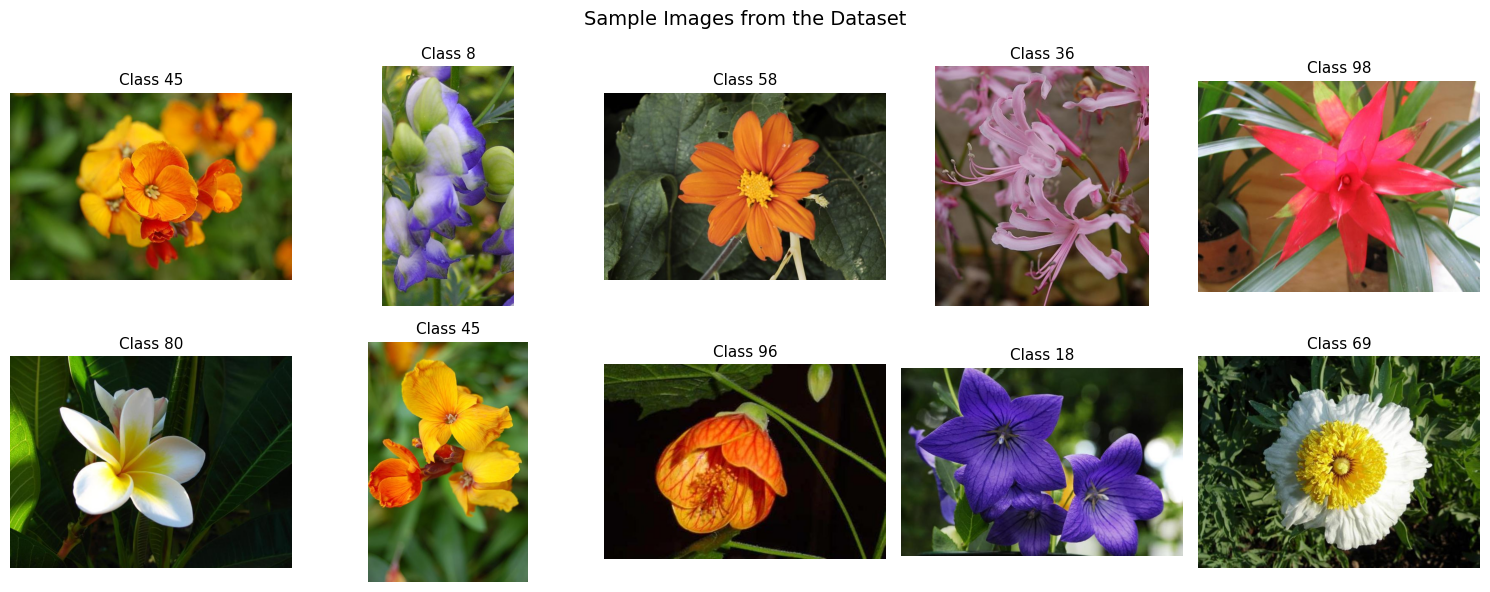

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

random_indices = np.random.choice(len(labels), size=10, replace=False)

for ax, idx in zip(axes.flat, random_indices):
    img_path = os.path.join(path_dataset, "jpg", f"image_{idx+1:05d}.jpg")
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(f"Class {labels[idx]}", fontsize=11)
    ax.axis("off")

plt.suptitle("Sample Images from the Dataset", fontsize=14)
plt.tight_layout()
plt.show()

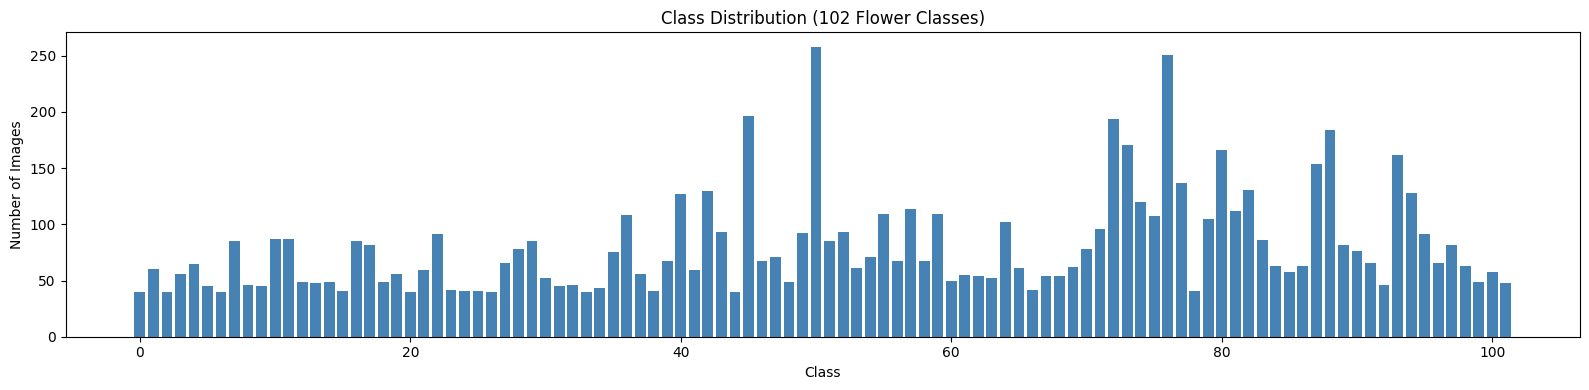

Min images per class: 40
Max images per class: 258
Mean images per class: 80.3


In [ ]:
# Plot class distribution
class_counts = np.bincount(labels)

plt.figure(figsize=(16, 4))
plt.bar(range(len(class_counts)), class_counts, color="steelblue")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution (102 Flower Classes)")
plt.tight_layout()
plt.show()

print(f"Min images per class: {class_counts.min()}")
print(f"Max images per class: {class_counts.max()}")
print(f"Mean images per class: {class_counts.mean():.1f}")

## Dataset Class

In [ ]:
class FlowerDataset(Dataset):
    def __init__(self, data_dir="flower_data", transform=None):
        self.image_dir = os.path.join(data_dir, "jpg")
        self.transform = transform

        labels_mat = scipy.io.loadmat(os.path.join(data_dir, "imagelabels.mat"))
        self.labels = labels_mat["labels"].flatten() - 1  # 0-indexed

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, f"image_{idx+1:05d}.jpg")
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]
        return image, label

## Define transform

In [ ]:
# ImageNet stats
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

 ## Train / Val / Test Split

In [ ]:
# Create the full dataset
full_dataset = FlowerDataset(data_dir="flower_data")

# Split sizes: 70 / 15 / 15
total = len(full_dataset)
train_size = int(0.70 * total)
val_size = int(0.15 * total)
test_size = total - train_size - val_size

# Fixed seed for reproducibility
generator = torch.Generator().manual_seed(42)
train_subset, val_subset, test_subset = random_split(
    full_dataset, [train_size, val_size, test_size], generator=generator
)

print(f"Train: {len(train_subset)}  |  Val: {len(val_subset)}  |  Test: {len(test_subset)}")

Train: 5732  |  Val: 1228  |  Test: 1229


### Transform the subset

In [ ]:
class TransformedSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = TransformedSubset(train_subset, train_transform)
val_dataset = TransformedSubset(val_subset, val_test_transform)
test_dataset = TransformedSubset(test_subset, val_test_transform)

## DataLoaders

In [ ]:
batch_size = 32

# Use num_workers to load data in parallel, and pin_memory for faster transfer to GPU
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}  |  Test batches: {len(test_loader)}")

Train batches: 180  |  Val batches: 39  |  Test batches: 39


## Optuna Hyperparameter Search (ResNet18 vs EfficientNet-B0)

In [ ]:
def objective(trial):
    # --- Model selection ---
    model_name = trial.suggest_categorical("model", [
        "resnet18", "efficientnet_b0", "densenet121", "convnext_tiny"
    ])

    if model_name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        for param in model.parameters():
            param.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features, 102)

    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        for param in model.parameters():
            param.requires_grad = False
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 102)

    elif model_name == "densenet121":
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        for param in model.parameters():
            param.requires_grad = False
        model.classifier = nn.Linear(model.classifier.in_features, 102)

    elif model_name == "convnext_tiny":
        model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        for param in model.parameters():
            param.requires_grad = False
        model.classifier[2] = nn.Linear(model.classifier[2].in_features, 102)

    # Unfreeze last N layers
    unfreeze_layers = trial.suggest_int("unfreeze_layers", 0, 3)
    if unfreeze_layers > 0:
        params_list = list(model.parameters())
        for param in params_list[-unfreeze_layers:]:
            param.requires_grad = True

    model = model.to(device)

    # --- Training hyperparameters ---
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    label_smoothing = trial.suggest_float("label_smoothing", 0.0, 0.2)
    augment_strength = trial.suggest_categorical("augment_strength", ["light", "medium", "heavy"])
    optimizer_name = trial.suggest_categorical("optimizer", ["adam", "sgd"])
    scheduler_name = trial.suggest_categorical("scheduler", ["cosine", "step", "plateau"])

    # --- Augmentation based on strength ---
    if augment_strength == "light":
        train_tf = transforms.Compose([
            transforms.RandomResizedCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
        ])
    elif augment_strength == "medium":
        train_tf = transforms.Compose([
            transforms.RandomResizedCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.RandomRotation(15),
            transforms.ToTensor(),
            transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
        ])
    else:  # heavy
        train_tf = transforms.Compose([
            transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
            transforms.RandomRotation(30),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
            transforms.ToTensor(),
            transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
        ])

    # Rebuild dataloaders with trial's batch size and augmentation
    trial_train_dataset = TransformedSubset(train_subset, train_tf)
    trial_val_dataset = TransformedSubset(val_subset, val_test_transform)
    trial_train_loader = DataLoader(trial_train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    trial_val_loader = DataLoader(trial_val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    # --- Optimizer ---
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())
    if optimizer_name == "adam":
        optimizer = optim.Adam(trainable_params, lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.SGD(trainable_params, lr=lr, momentum=0.9, weight_decay=weight_decay)

    # --- Scheduler ---
    n_epochs = 5
    if scheduler_name == "cosine":
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    elif scheduler_name == "step":
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
    else:  # plateau
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=1, factor=0.5)

    # --- Loss with label smoothing ---
    loss_fn = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    # --- Training loop ---
    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in tqdm(trial_train_loader, desc=f"Epoch {epoch+1}", leave=False):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(trial_train_loader)

        # Step scheduler
        if scheduler_name == "plateau":
            scheduler.step(avg_train_loss)
        else:
            scheduler.step()

        # Validation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in trial_val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total

        # Pruning
        trial.report(accuracy, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return accuracy

In [ ]:
from optuna.pruners import MedianPruner

study = optuna.create_study(
    direction="maximize",
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=2)
)

n_trials = 30
print(f"Starting Optuna search: {n_trials} trials ...")

study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

print(f"\nBest validation accuracy: {study.best_value:.2f}%")
print("Best hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-03-04 00:25:20,954] A new study created in memory with name: no-name-572f3c72-5bcc-4f7a-ae5f-ba90d9c54689


Starting Optuna search: 30 trials ...


  0%|          | 0/30 [00:00<?, ?it/s]

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth



  0%|          | 0.00/44.7M [00:00<?, ?B/s]
 20%|█▉        | 8.88M/44.7M [00:00<00:00, 92.7MB/s]
100%|██████████| 44.7M/44.7M [00:00<00:00, 181MB/s]


...

[I 2026-03-04 01:06:44,637] Trial 28 pruned. 


Epoch 1:   0%|          | 0/359 [00:00<?, ?it/s]

Epoch 2:   0%|          | 0/359 [00:00<?, ?it/s]

Epoch 3:   0%|          | 0/359 [00:00<?, ?it/s]

[I 2026-03-04 01:08:16,886] Trial 29 pruned. 

Best validation accuracy: 96.74%
Best hyperparameters:
  model: convnext_tiny
  unfreeze_layers: 0
  lr: 0.0019212734913548128
  weight_decay: 4.4951148095251195e-05
  dropout_rate: 0.40585322586991684
  batch_size: 16
  label_smoothing: 0.05018896409911262
  augment_strength: medium
  optimizer: adam
  scheduler: cosine


/tmp/ipykernel_14972/1445341484.py:4: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


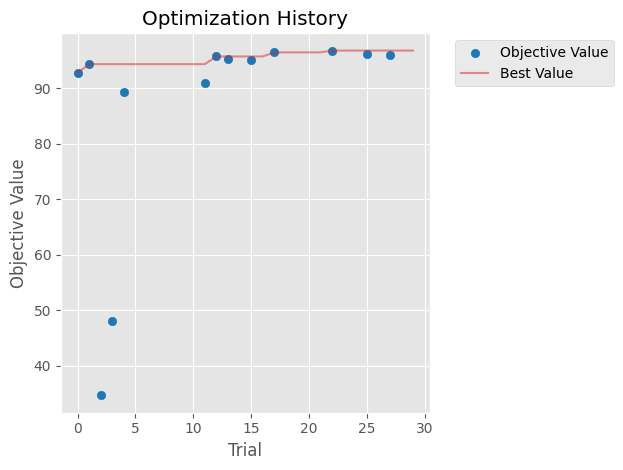

/tmp/ipykernel_14972/1445341484.py:10: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


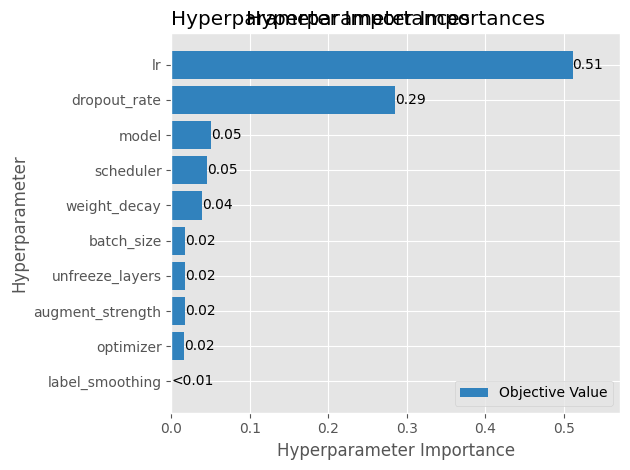

/tmp/ipykernel_14972/1445341484.py:16: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_parallel_coordinate(


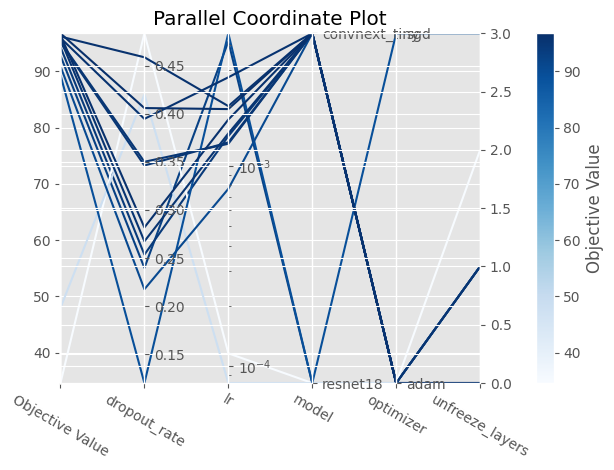

In [ ]:
# Visualize Optuna results

# 1. Optimization history
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title("Optimization History")
plt.tight_layout()
plt.show()

# 2. Hyperparameter importances
optuna.visualization.matplotlib.plot_param_importances(study)
plt.title("Hyperparameter Importances")
plt.tight_layout()
plt.show()

# 3. Parallel coordinate plot — updated for all new hyperparameters
optuna.visualization.matplotlib.plot_parallel_coordinate(
    study, params=[
        "model", "lr", "optimizer", "scheduler",
        "unfreeze_layers", "dropout_rate", "weight_decay",
        "batch_size", "augment_strength", "label_smoothing"
    ]
)
plt.gcf().set_size_inches(18, 6)
plt.tight_layout()
plt.show()

# 4. Trial results table
df = study.trials_dataframe()
df.sort_values("value", ascending=False).head(10)

## Train the best model

In [ ]:
best = study.best_params

# Rebuild the best model
if best["model"] == "resnet18":
    best_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for param in best_model.parameters():
        param.requires_grad = False
    best_model.fc = nn.Linear(best_model.fc.in_features, 102)

elif best["model"] == "efficientnet_b0":
    best_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    for param in best_model.parameters():
        param.requires_grad = False
    best_model.classifier[1] = nn.Linear(best_model.classifier[1].in_features, 102)

elif best["model"] == "densenet121":
    best_model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    for param in best_model.parameters():
        param.requires_grad = False
    best_model.classifier = nn.Linear(best_model.classifier.in_features, 102)

elif best["model"] == "convnext_tiny":
    best_model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
    for param in best_model.parameters():
        param.requires_grad = False
    best_model.classifier[2] = nn.Linear(best_model.classifier[2].in_features, 102)

# Unfreeze the best number of layers
if best["unfreeze_layers"] > 0:
    params_list = list(best_model.parameters())
    for param in params_list[-best["unfreeze_layers"]:]:
        param.requires_grad = True

best_model = best_model.to(device)

# Setup optimizer with weight decay
trainable_params = filter(lambda p: p.requires_grad, best_model.parameters())
if best["optimizer"] == "adam":
    optimizer = optim.Adam(trainable_params, lr=best["lr"], weight_decay=best["weight_decay"])
else:
    optimizer = optim.SGD(trainable_params, lr=best["lr"], momentum=0.9, weight_decay=best["weight_decay"])

# Setup scheduler
n_epochs = 30
if best["scheduler"] == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
elif best["scheduler"] == "step":
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
else:
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)

# Loss with label smoothing
loss_fn = nn.CrossEntropyLoss(label_smoothing=best["label_smoothing"])

# Rebuild train loader with best augmentation
if best["augment_strength"] == "light":
    best_train_tf = transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])
elif best["augment_strength"] == "medium":
    best_train_tf = transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])
else:
    best_train_tf = transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
        transforms.RandomRotation(30),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])

best_train_dataset = TransformedSubset(train_subset, best_train_tf)
train_loader = DataLoader(best_train_dataset, batch_size=best["batch_size"], shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=best["batch_size"], shuffle=False, num_workers=0)

print(f"Model:       {best['model']}")
print(f"Optimizer:   {best['optimizer']}, LR: {best['lr']:.6f}, Weight Decay: {best['weight_decay']:.6f}")
print(f"Scheduler:   {best['scheduler']}")
print(f"Dropout:     {best['dropout_rate']:.4f}")
print(f"Unfrozen:    {best['unfreeze_layers']} layers")
print(f"Batch size:  {best['batch_size']}")
print(f"Augmentation:{best['augment_strength']}")
print(f"Label smooth:{best['label_smoothing']:.4f}")

Model:       convnext_tiny
Optimizer:   adam, LR: 0.001921, Weight Decay: 0.000045
Scheduler:   cosine
Dropout:     0.4059
Unfrozen:    0 layers
Batch size:  16
Augmentation:medium
Label smooth:0.0502


In [ ]:
# Training loop with scheduler and early stopping
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0
best_weights = None
patience_counter = 0
patience = 7

for epoch in range(n_epochs):
    # --- Train ---
    best_model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = best_model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_losses.append(running_loss / total)
    train_accs.append(100 * correct / total)

    # --- Validate ---
    best_model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = best_model(images)
            loss = loss_fn(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_losses.append(running_loss / total)
    val_accs.append(100 * correct / total)

    # Step scheduler
    if best["scheduler"] == "plateau":
        scheduler.step(val_losses[-1])
    else:
        scheduler.step()

    # Early stopping
    if val_accs[-1] > best_val_acc:
        best_val_acc = val_accs[-1]
        best_weights = copy.deepcopy(best_model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch+1:2d}/{n_epochs} | "
          f"Train Loss: {train_losses[-1]:.4f}  Acc: {train_accs[-1]:.2f}% | "
          f"Val Loss: {val_losses[-1]:.4f}  Acc: {val_accs[-1]:.2f}% | "
          f"LR: {current_lr:.6f}")

    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}. No improvement for {patience} epochs.")
        break

# Load best weights
best_model.load_state_dict(best_weights)
print(f"\nBest Val Accuracy: {best_val_acc:.2f}%")

Epoch  1/30 | Train Loss: 1.9866  Acc: 65.11% | Val Loss: 0.9320  Acc: 91.29% | LR: 0.001916
Epoch  2/30 | Train Loss: 1.0391  Acc: 87.58% | Val Loss: 0.7948  Acc: 94.38% | LR: 0.001900
Epoch  3/30 | Train Loss: 0.8971  Acc: 91.22% | Val Loss: 0.7533  Acc: 95.68% | LR: 0.001874
Epoch  4/30 | Train Loss: 0.8513  Acc: 92.18% | Val Loss: 0.7241  Acc: 96.74% | LR: 0.001838
Epoch  5/30 | Train Loss: 0.8130  Acc: 93.51% | Val Loss: 0.7414  Acc: 95.77% | LR: 0.001793
Epoch  6/30 | Train Loss: 0.7906  Acc: 94.12% | Val Loss: 0.7124  Acc: 96.01% | LR: 0.001738
Epoch  7/30 | Train Loss: 0.7710  Acc: 94.47% | Val Loss: 0.7037  Acc: 96.34% | LR: 0.001675
Epoch  8/30 | Train Loss: 0.7607  Acc: 94.70% | Val Loss: 0.7253  Acc: 96.01% | LR: 0.001603
Epoch  9/30 | Train Loss: 0.7726  Acc: 94.12% | Val Loss: 0.6993  Acc: 97.23% | LR: 0.001525
Epoch 10/30 | Train Loss: 0.7372  Acc: 95.48% | Val Loss: 0.6833  Acc: 97.07% | LR: 0.001441
Epoch 11/30 | Train Loss: 0.7417  Acc: 95.60% | Val Loss: 0.6829  Acc:

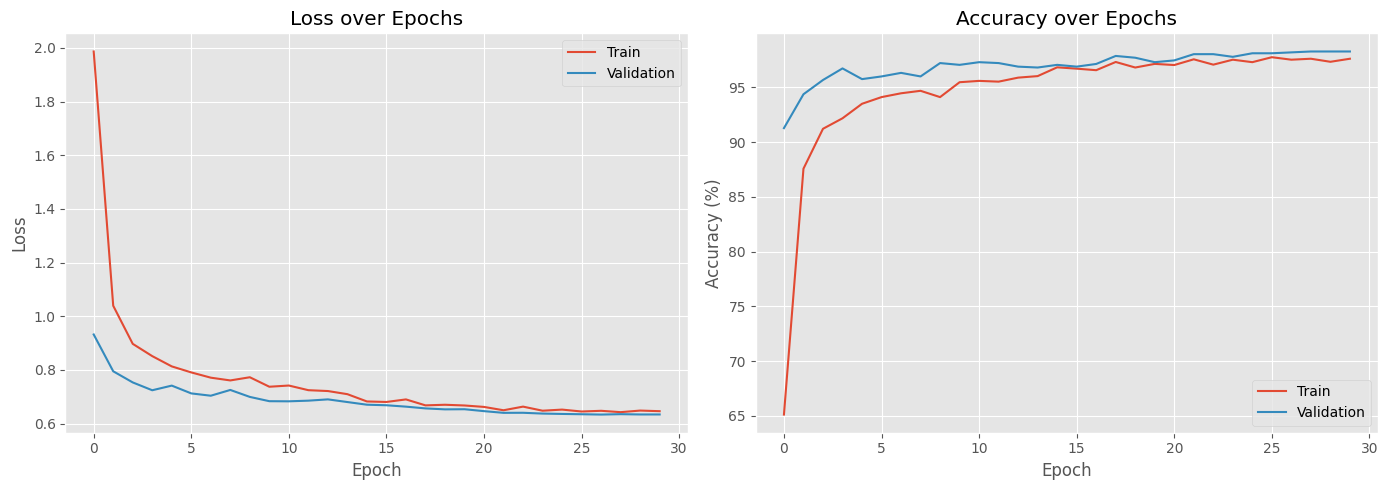


Final Val Accuracy: 98.29%
Best Val Accuracy: 98.29% (Epoch 28)


In [ ]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label="Train")
ax1.plot(val_losses, label="Validation")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss over Epochs")
ax1.legend()

ax2.plot(train_accs, label="Train")
ax2.plot(val_accs, label="Validation")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Accuracy over Epochs")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nFinal Val Accuracy: {val_accs[-1]:.2f}%")
print(f"Best Val Accuracy: {max(val_accs):.2f}% (Epoch {val_accs.index(max(val_accs))+1})")

## Test Set Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

best_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = best_model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_accuracy = 100 * np.sum(all_preds == all_labels) / len(all_labels)
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 97.80%


In [ ]:
# Classification report (top-level metrics per class)
print(classification_report(all_labels, all_preds, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         7
           2       1.00      0.90      0.95        10
           3       0.83      1.00      0.91        10
           4       1.00      0.91      0.95        11
           5       1.00      1.00      1.00         6
           6       0.88      1.00      0.93         7
           7       1.00      1.00      1.00        11
           8       1.00      1.00      1.00         5
           9       1.00      1.00      1.00         9
          10       0.87      1.00      0.93        13
          11       0.90      1.00      0.95         9
          12       1.00      0.67      0.80         3
          13       1.00      1.00      1.00         7
          14       1.00      1.00      1.00        10
          15       0.83      1.00      0.91         5
          16       1.00      1.00      1.00        11
          17       1.00    

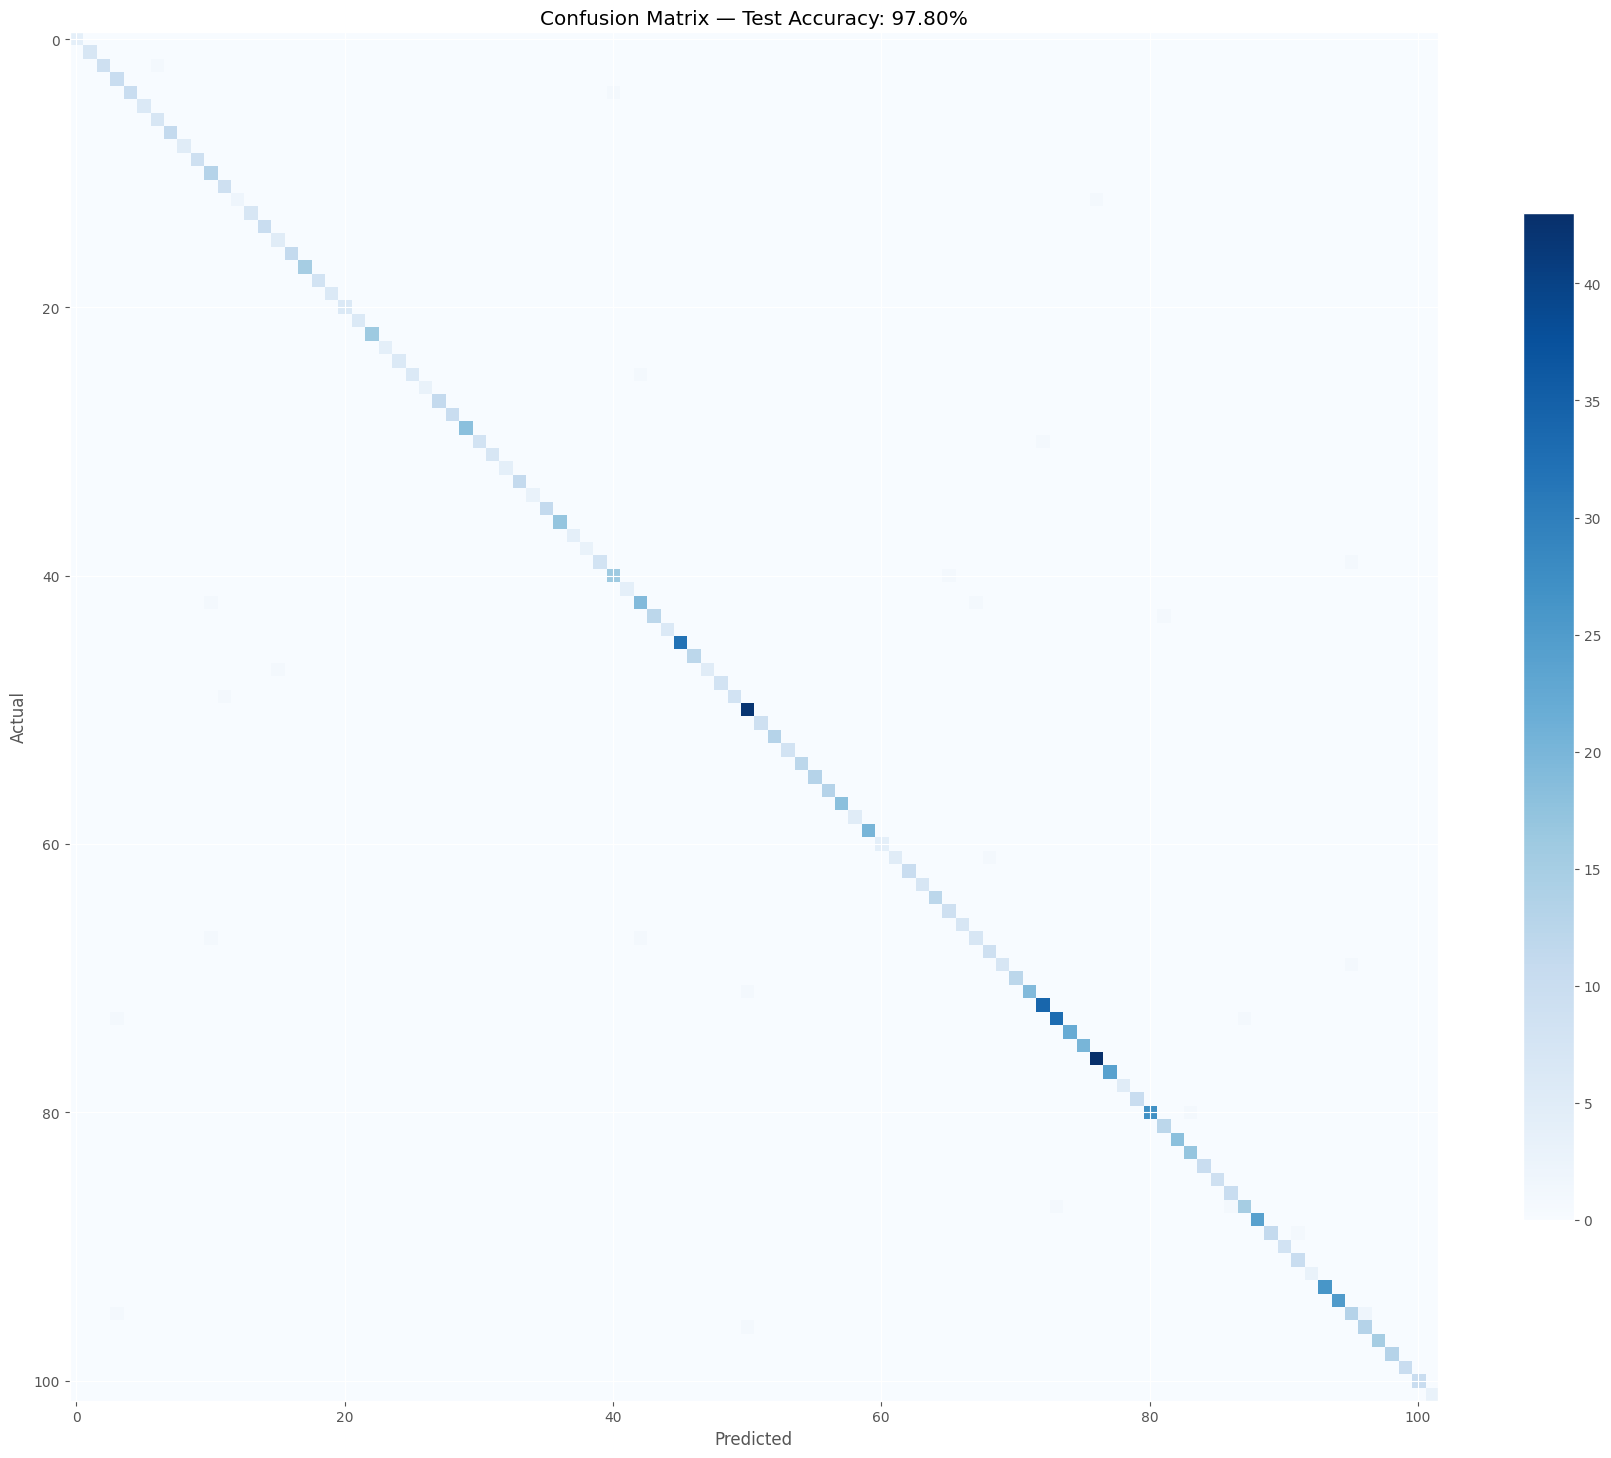

In [ ]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(18, 15))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(shrink=0.7)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — Test Accuracy: {test_accuracy:.2f}%")
plt.tight_layout()
plt.show()

In [ ]:
## Visualize Predictions

In [ ]:
# Helper to denormalize images for display
def denormalize(tensor):
    mean = torch.tensor(imagenet_mean).view(3, 1, 1)
    std = torch.tensor(imagenet_std).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1)

In [1]:
# Show correct predictions
correct_mask = all_preds == all_labels
correct_indices = np.where(correct_mask)[0]
random_correct = np.random.choice(correct_indices, size=10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax, idx in zip(axes.flat, random_correct):
    image, _ = test_dataset[idx]
    ax.imshow(denormalize(image).permute(1, 2, 0))
    ax.set_title(f"Pred: {all_preds[idx]}  |  True: {all_labels[idx]}", fontsize=10, color="green")
    ax.axis("off")

plt.suptitle("Correct Predictions", fontsize=14)
plt.tight_layout()
plt.show()

NameError: name 'all_preds' is not defined

## Save Model

In [ ]:
torch.save({
    "model_state_dict": best_model.state_dict(),
    "best_params": study.best_params,
    "test_accuracy": test_accuracy,
}, "best_flower_model.pth")

print("Model saved to 'best_flower_model.pth'")
print(f"  Model: {study.best_params['model']}")
print(f"  Test Accuracy: {test_accuracy:.2f}%")

Model saved to 'best_flower_model.pth'
  Model: convnext_tiny
  Test Accuracy: 97.80%
